# Aplicação de Modelos de Markov e Redes Neurais LSTM na Previsão de Arrecadação do ICMS Paulista
## Resultados dos Experimentos Univariados e Multivariados para as Previsões Anuais de 2013 a 2022

### Antonio Sergio Ferreira Bonato

Atualmente, na Secretaria da Fazenda e Planejamento do Estado de São Paulo, a previsão de arrecadação do ICMS paulista é feita usando-se um modelo ARIMA com variáveis exógenas, o ARIMAX. Mas o ICMS é não linear e há várias quebras estruturais controladas com diversas *dummies*. A consequência é um modelo bastante sobreajustado, inadequado para previsões de mais longo prazo (mais do que alguns meses, muito menos para um ano). 
A proposta deste trabalho é utilizar modelos não lineares multivariados na previsão do ICMS paulista, utilizando redes neurais recorrentes LSTM (*Long Short Term Memory*) e modelos Markov-Switching, fazendo um contraponto entre estes dois modelos. E utilizar, como baseline de comparação, o modelo ARIMAX atual. 

**Palavras-chave**: Markov-Switching Models. Redes Neurais Recorrentes. LSTM. ICMS.

## Análise dos Resultados

In [41]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random
seed = 42
random.seed(seed)
np.random.seed(seed)

sns.set()
sns.set_context("notebook")
sns.set(rc={'figure.figsize':(10,7)})

In [42]:
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

In [43]:
df_metricas_all = pd.read_excel("metricas.xlsx")
df_metricas_all.head()

,metrica,RMSE,MAPE,ano,experimento,estratégia,BIC,MAPE Val,Escolha
0,Mean,8.680759e+08,0.071311,2013,univariado,naive,NaN,NaN,1
1,"SARIMA(0,1,1),(1,0,1)",3.634953e+08,0.032571,2013,univariado,sarima,-405.970850,NaN,1
2,"SARIMAX(2,1,1),(1,0,1)",3.502613e+08,0.030468,2013,univariado,sarimax,-438.028928,NaN,0
3,"SARIMAX(0,1,1),(1,0,1)",3.252917e+08,0.028308,2013,univariado,sarimax,-445.761862,NaN,1
4,Markov-Fixed,6.408498e+08,0.063012,2013,univariado,markov-switching,-3.410553,NaN,1


In [44]:
print(df_metricas_all.loc[
    (df_metricas_all.ano==2022) & 
    (df_metricas_all.experimento=='univariado'), ['metrica', 'estratégia',
                                'BIC', 'MAPE Val', 'Escolha']].to_latex(index=False))

\begin{tabular}{llrrr}
\toprule
                metrica &        estratégia &         BIC &  MAPE Val &  Escolha \\
\midrule
                   Mean &             naive &         NaN &       NaN &        1 \\
  SARIMA(0,1,1),(2,0,1) &            sarima & -761.133000 &       NaN &        0 \\
  SARIMA(0,1,1),(1,0,1) &            sarima & -761.151000 &       NaN &        1 \\
 SARIMAX(0,1,1),(2,0,0) &           sarimax & -815.743000 &       NaN &        0 \\
 SARIMAX(0,1,1),(1,0,1) &           sarimax & -818.740000 &       NaN &        1 \\
           Markov-Fixed &  markov-switching &   -3.297937 &       NaN &        0 \\
   Markov-Switching-Var &  markov-switching &   -3.341894 &       NaN &        0 \\
        Markov-Mean-Var &  markov-switching &   -3.353027 &       NaN &        1 \\
         RNN-LSTM-1-mês &          rnn-lstm &         NaN &  0.109748 &        0 \\
      RNN-LSTM-12-meses &          rnn-lstm &         NaN &  0.095597 &        1 \\
\bottomrule
\end{tabular}



In [45]:
print(df_metricas_all.loc[
    (df_metricas_all.ano==2022) & 
    (df_metricas_all.experimento=='multivariado'), ['metrica', 'estratégia',
                                'BIC', 'MAPE Val', 'Escolha']].to_latex(index=False))

\begin{tabular}{llrrr}
\toprule
                metrica &        estratégia &         BIC &  MAPE Val &  Escolha \\
\midrule
  SARIMAX(0,1,1)(2,0,1) &           sarimax & -829.795000 &       NaN &        0 \\
 SARIMAX(0,1,1),(1,0,1) &           sarimax & -830.139000 &       NaN &        1 \\
           Markov-Fixed &  markov-switching &   -3.300642 &       NaN &        0 \\
   Markov-Switching-Var &  markov-switching &   -3.334533 &       NaN &        0 \\
        Markov-Mean-Var &  markov-switching &   -3.356496 &       NaN &        1 \\
               RNN-LSTM &          rnn-lstm &         NaN &   0.06552 &        1 \\
\bottomrule
\end{tabular}



### Filtram-se somente os modelos escolhidos de cada experimento e estratégia

In [46]:
df_metricas = df_metricas_all[df_metricas_all.Escolha == 1].copy()

## Menor MAPE por experimento por ano
Independente de estratégia, menor MAPE para o experimento univariado e multivariado.

Text(0.5, 1.0, 'Menor MAPE por Experimento')

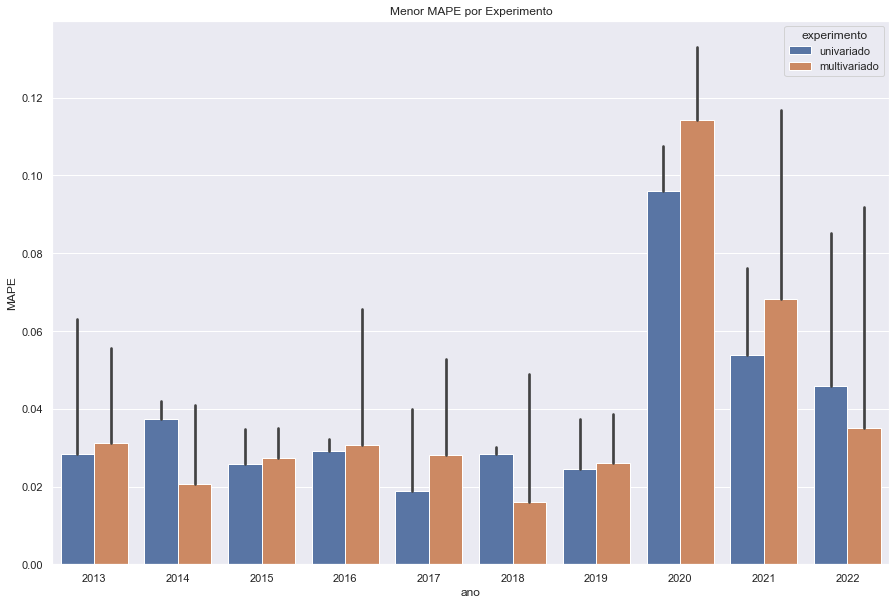

In [47]:
fig = plt.figure(figsize=(15, 10))
ax = sns.barplot(x='ano', y='MAPE', data=df_metricas, hue='experimento', estimator=min)
ax.set_title('Menor MAPE por Experimento')
#_ = plt.xticks(rotation=45)

### Média dos MAPE por Ano de Todos os Experimentos e Estratégias

Text(0.5, 1.0, 'Média dos MAPE por Ano dos Melhores Modelos por Estratégia')

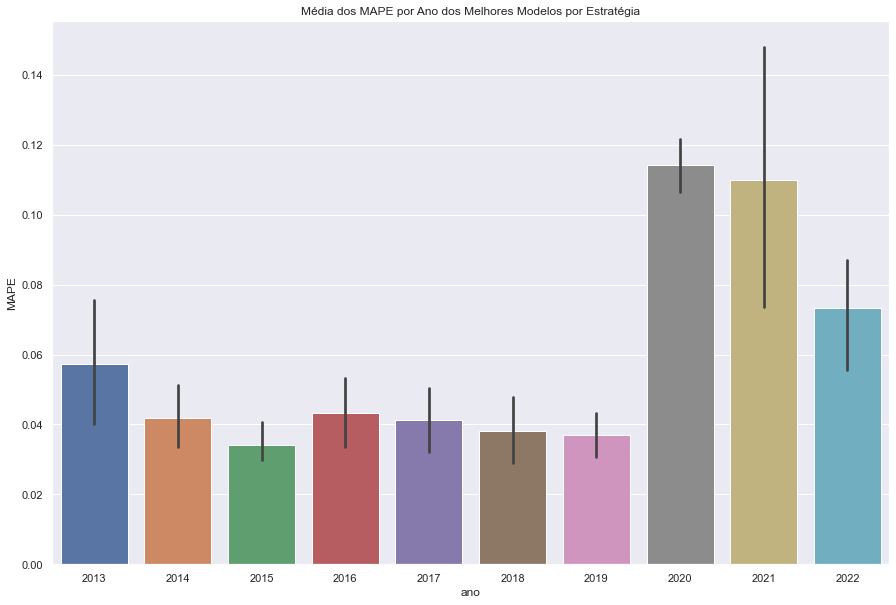

In [48]:
fig = plt.figure(figsize=(15, 10))
ax = sns.barplot(x='ano', y='MAPE', data=df_metricas)
ax.set_title('Média dos MAPE por Ano dos Melhores Modelos por Estratégia')

### MAPE de Cada Estratégia, por Ano, por Experimento Multivariado

In [49]:
df_multi = df_metricas[df_metricas['experimento']=='multivariado']

Text(0.5, 1.0, 'MAPE por Ano dos Melhores Modelos por Estratégia dos Experimento Multivariados')

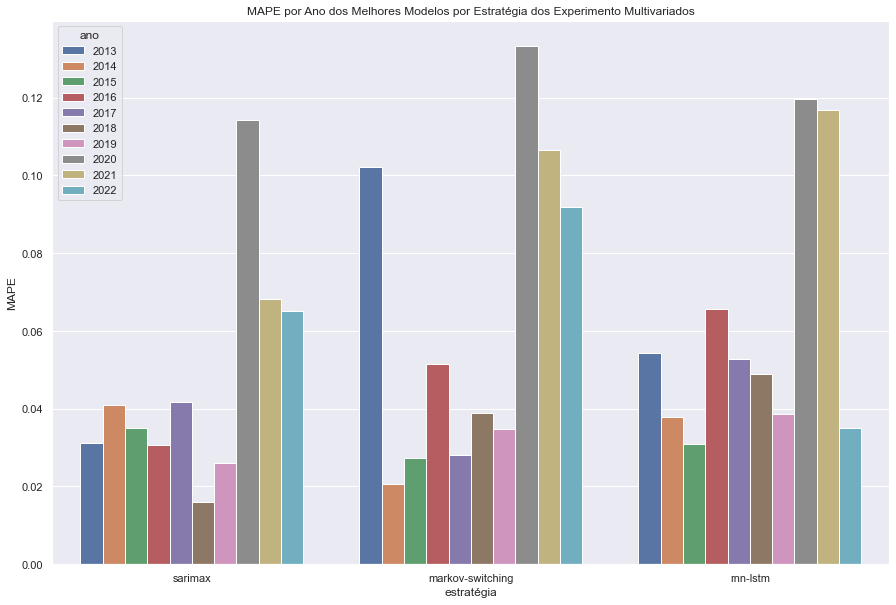

In [50]:
fig = plt.figure(figsize=(15, 10))
ax = sns.barplot(x='estratégia', y='MAPE', data=df_multi, hue='ano')
ax.set_title('MAPE por Ano dos Melhores Modelos por Estratégia dos Experimento Multivariados')

### MAPE de Cada Estratégia, por Ano, por Experimento Univariado

In [51]:
df_uni = df_metricas[df_metricas['experimento']=='univariado']

Text(0.5, 1.0, 'MAPE por Ano dos Melhores Modelos por Estratégia dos Experimento Univariados')

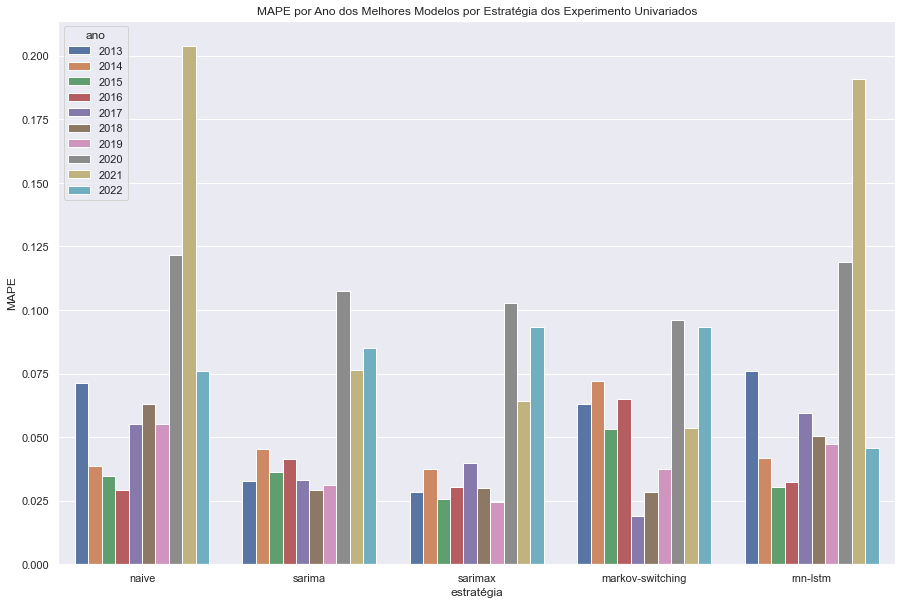

In [52]:
fig = plt.figure(figsize=(15, 10))
ax = sns.barplot(x='estratégia', y='MAPE', data=df_uni, hue='ano')
ax.set_title('MAPE por Ano dos Melhores Modelos por Estratégia dos Experimento Univariados')

## MAPE por estratégia por ano

### Experimento univariado

Text(0.5, 1.0, 'MAPE por Estratégia por Ano para o Experimento Univariado')

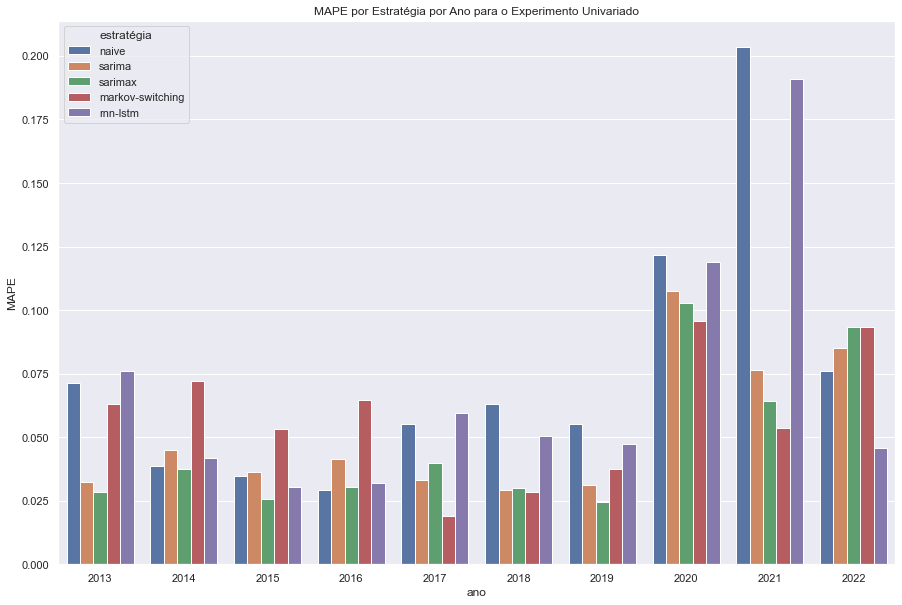

In [53]:
fig = plt.figure(figsize=(15, 10))
ax = sns.barplot(x='ano', y='MAPE', data=df_metricas[df_metricas.experimento == "univariado"], 
                 hue='estratégia')
ax.set_title('MAPE por Estratégia por Ano para o Experimento Univariado')
#_ = plt.xticks(rotation=45)

### Experimento multivariado

Text(0.5, 1.0, 'MAPE por Estratégia por Ano para o Experimento Univariado')

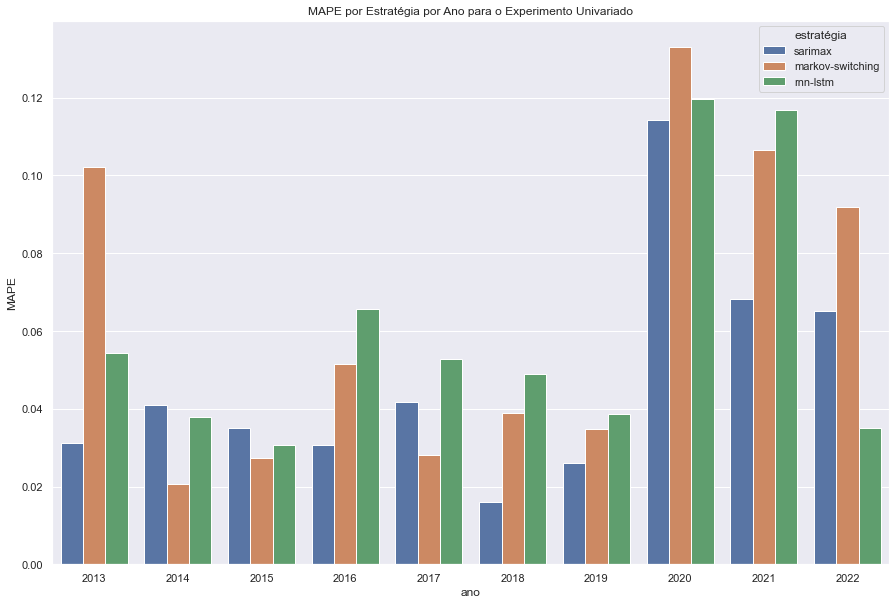

In [54]:
fig = plt.figure(figsize=(15, 10))
ax = sns.barplot(x='ano', y='MAPE', data=df_metricas[df_metricas.experimento == "multivariado"], 
                 hue='estratégia')
ax.set_title('MAPE por Estratégia por Ano para o Experimento Univariado')
#_ = plt.xticks(rotation=45)

## Menor MAPE do Ano, independente de experimento e estratégia

In [55]:
idx = df_metricas.groupby('ano')['MAPE'].idxmin()
df_min_mape = df_metricas.loc[idx, ['ano', 'experimento', 'estratégia', 'RMSE', 'MAPE']]
df_min_mape

,ano,experimento,estratégia,RMSE,MAPE
3,2013,univariado,sarimax,3.252917e+08,0.028308
24,2014,multivariado,markov-switching,2.452290e+08,0.020532
28,2015,univariado,sarimax,3.383003e+08,0.025731
38,2016,univariado,naive,3.592372e+08,0.029089
55,2017,univariado,markov-switching,2.717801e+08,0.018942
74,2018,multivariado,sarimax,2.371184e+08,0.016031
82,2019,univariado,sarimax,3.803392e+08,0.024521
97,2020,univariado,markov-switching,1.411437e+09,0.095877
112,2021,univariado,markov-switching,1.036629e+09,0.053760
136,2022,multivariado,rnn-lstm,6.599282e+08,0.035033


### Menor MAPE por Estratégia por Ano Independente de Experimento

Text(0.5, 1.0, 'Estratégia com Menor MAPE por Ano')

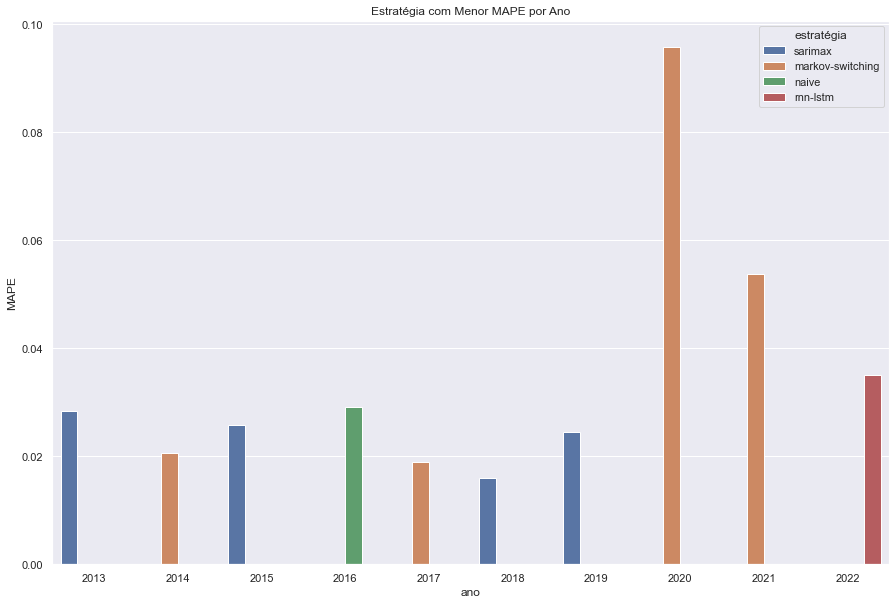

In [56]:
fig = plt.figure(figsize=(15, 10))
ax = sns.barplot(x='ano', y='MAPE', data=df_min_mape, hue='estratégia')
ax.set_title('Estratégia com Menor MAPE por Ano')

### Menor MAPE por Experimento por Ano Independente de Estratégia

Text(0.5, 1.0, 'Experimento com Menor MAPE por Ano')

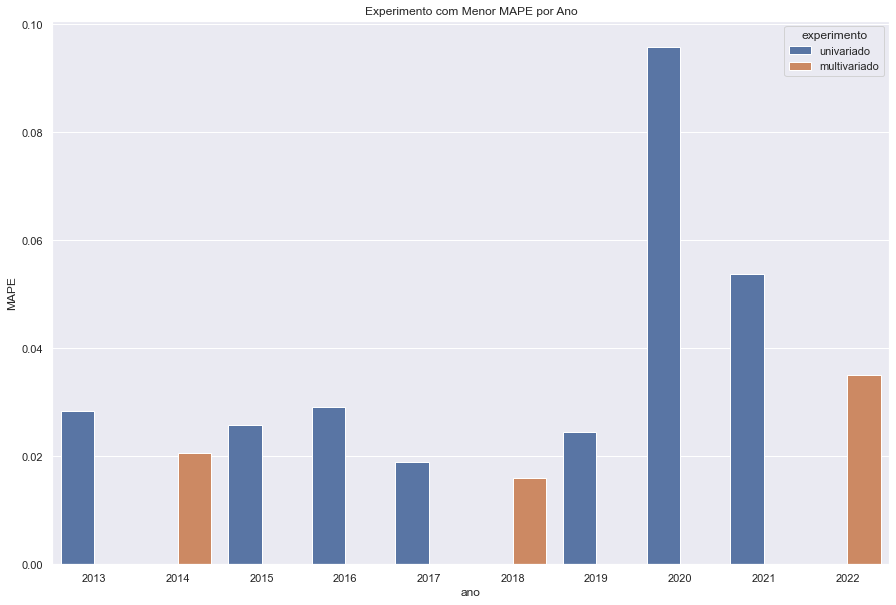

In [57]:
fig = plt.figure(figsize=(15, 10))
ax = sns.barplot(x='ano', y='MAPE', data=df_min_mape, hue='experimento')
ax.set_title('Experimento com Menor MAPE por Ano')

## Menor MAPE do Ano por experimento

In [58]:
idx_est = df_metricas.groupby(['ano', 'experimento'])['MAPE'].idxmin()
df_min_mape_est = df_metricas.loc[idx_est, ['ano', 'experimento', 'estratégia', 'RMSE', 'MAPE']]
df_min_mape_est.head()

,ano,experimento,estratégia,RMSE,MAPE
9,2013,multivariado,sarimax,3.840274e+08,0.031141
3,2013,univariado,sarimax,3.252917e+08,0.028308
24,2014,multivariado,markov-switching,2.452290e+08,0.020532
15,2014,univariado,sarimax,4.347452e+08,0.037423
36,2015,multivariado,markov-switching,3.599555e+08,0.027291


### Menor MAPE por Estratégia por Ano por Experimento Univariado

Text(0.5, 1.0, 'Estratégia com Menor MAPE por Ano')

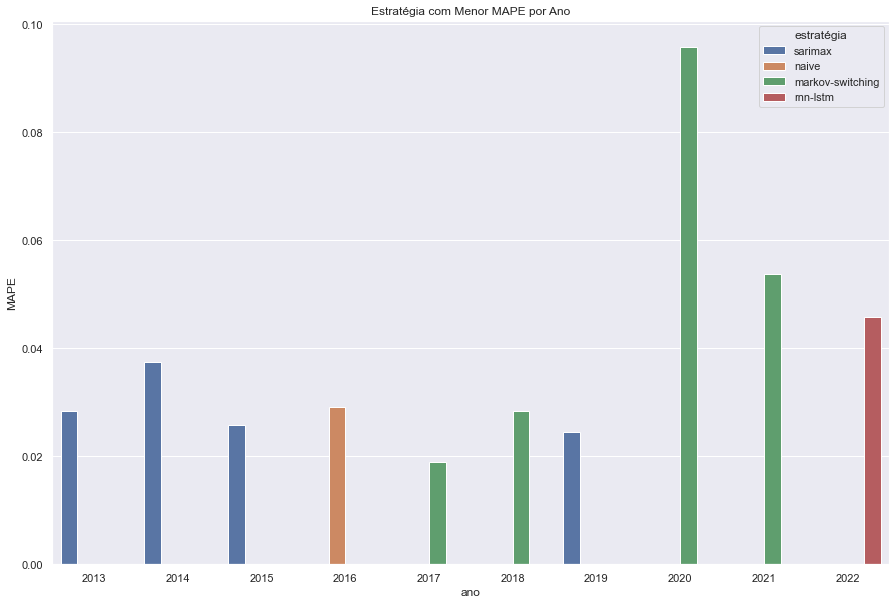

In [59]:
fig = plt.figure(figsize=(15, 10))
ax = sns.barplot(x='ano', y='MAPE', data=df_min_mape_est[df_min_mape_est.experimento == 'univariado'], 
                 hue='estratégia')
ax.set_title('Estratégia com Menor MAPE por Ano')

### Menor MAPE por Estratégia por Ano por Experimento Multivariado

Text(0.5, 1.0, 'Estratégia com Menor MAPE por Ano')

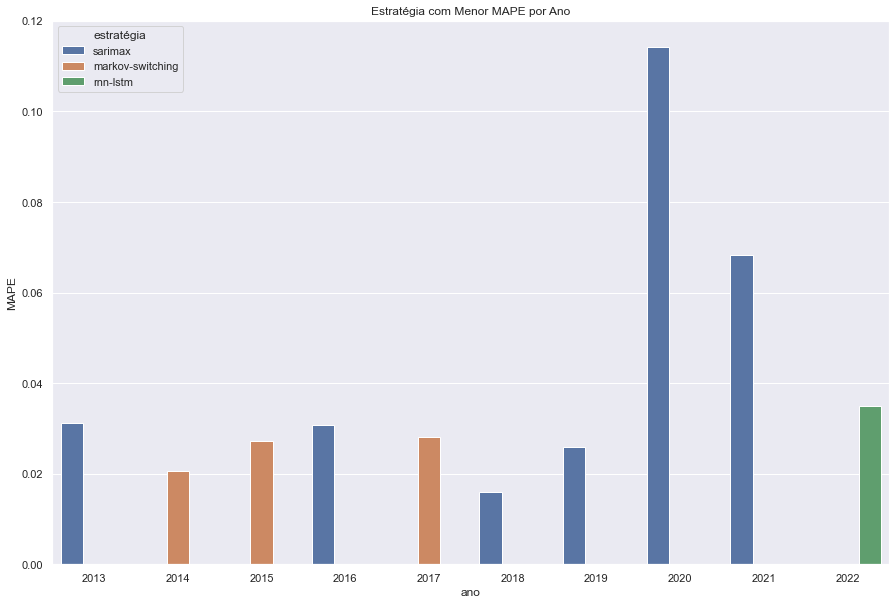

In [60]:
fig = plt.figure(figsize=(15, 10))
ax = sns.barplot(x='ano', y='MAPE', data=df_min_mape_est[df_min_mape_est.experimento == 'multivariado'], 
                 hue='estratégia')
ax.set_title('Estratégia com Menor MAPE por Ano')

Text(0.5, 1.0, 'Menor MAPE por Experimento')

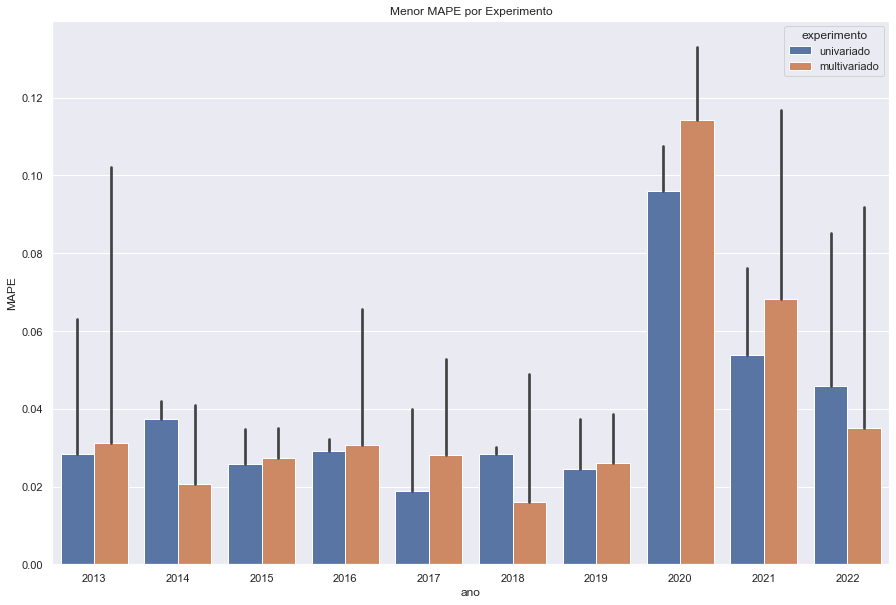

In [61]:
fig = plt.figure(figsize=(15, 10))
ax = sns.barplot(x='ano', y='MAPE', data=df_metricas, hue='experimento', estimator=np.min)
ax.set_title('Menor MAPE por Experimento')

In [62]:
arq = open('./mcs.txt', 'r')
print(arq.read())
arq.close()

Model naive univariado eliminated 2023-07-12 12:17:25
Model rnn-lstm univariado eliminated 2023-07-12 12:17:29
###########################################################################################
Superior Set Model created  :
                              Rank_M        v_M  MCS_M Rank_R        v_R  MCS_R       Loss
sarima univariado                  3 -3.1841050 1.0000      5  3.2055446 0.0000 0.05180554
sarimax univariado                 1 -4.4549511 1.0000      2  0.3473917 1.0000 0.04771008
markov-switching univariado        4  0.6041607 1.0000      3  1.6220337 0.5240 0.05808682
sarimax multivariado               2 -3.9382721 1.0000      1 -0.3473917 1.0000 0.04694450
markov-switching multivariado      6  1.5232446 0.3770      4  2.4993465 0.0236 0.06346838
rnn-lstm multivariado              5  1.0035961 0.9022      6  3.2630549 0.0000 0.06003565
p-value :
[1] 0.377

###########################################################################################



In [63]:
df_metricas_all

,metrica,RMSE,MAPE,ano,experimento,estratégia,BIC,MAPE Val,Escolha
0,Mean,8.680759e+08,0.071311,2013,univariado,naive,NaN,NaN,1
1,"SARIMA(0,1,1),(1,0,1)",3.634953e+08,0.032571,2013,univariado,sarima,-405.970850,NaN,1
2,"SARIMAX(2,1,1),(1,0,1)",3.502613e+08,0.030468,2013,univariado,sarimax,-438.028928,NaN,0
3,"SARIMAX(0,1,1),(1,0,1)",3.252917e+08,0.028308,2013,univariado,sarimax,-445.761862,NaN,1
4,Markov-Fixed,6.408498e+08,0.063012,2013,univariado,markov-switching,-3.410553,NaN,1
...,...,...,...,...,...,...,...,...,...
132,"SARIMAX(0,1,1),(1,0,1)",1.450859e+09,0.065208,2022,multivariado,sarimax,-830.139000,NaN,1
133,Markov-Fixed,1.545594e+09,0.076809,2022,multivariado,markov-switching,-3.300642,NaN,0
134,Markov-Switching-Var,1.397517e+09,0.063797,2022,multivariado,markov-switching,-3.334533,NaN,0
135,Markov-Mean-Var,1.695706e+09,0.091844,2022,multivariado,markov-switching,-3.356496,NaN,1


## Melhores estratégias considerando os melhores MAPEs.
Não seria possível utilizar esta forma de escolha das estratégias para previsão pois esta avaliação só pode ser feita a posteriori, isto é, quando se tem em mãos a série realizada. Entretanto, é um exercício válido para se entender quais teriam sido os melhores modelos caso critérios de escolha melhores do que os critérios de informação de Akaike e Schwarzs para os modelos SARIMA, SARIMAX e Markov-Switching ou o melhor MAPE em validação para as Redes Neurais estivessem disponíveis. 

### Experimentos Univariados

In [64]:
min_mape_uni = df_metricas_all[df_metricas_all.experimento=='univariado'].groupby(['ano'])[['MAPE']].min()
min_mape_uni

,MAPE
ano,
2013,0.028308
2014,0.030845
2015,0.025731
2016,0.029089
2017,0.018942
2018,0.027734
2019,0.024521
2020,0.095877
2021,0.053760


In [65]:
df_metricas_all[df_metricas_all.MAPE.isin(min_mape_uni.MAPE)][['ano', 'metrica',
                                                               'estratégia','MAPE']]

,ano,metrica,estratégia,MAPE
3,2013,"SARIMAX(0,1,1),(1,0,1)",sarimax,0.028308
18,2014,Markov-Mean-Var,markov-switching,0.030845
28,2015,"SARIMAX(0,1,1),(1,0,1)",sarimax,0.025731
38,2016,Mean,naive,0.029089
55,2017,Markov-Fixed,markov-switching,0.018942
67,2018,"SARIMAX(0,1,1),(1,0,2)",sarimax,0.027734
82,2019,"SARIMAX(0,1,1),(1,0,1)",sarimax,0.024521
97,2020,Markov-Switching-Var,markov-switching,0.095877
112,2021,Markov-Mean-Var,markov-switching,0.053760
129,2022,RNN-LSTM-1-mês,rnn-lstm,0.037627


In [66]:
df_metricas_all[df_metricas_all.MAPE.isin(min_mape_uni.MAPE)].groupby(['estratégia'])['estratégia'].count()

estratégia
markov-switching    4
naive               1
rnn-lstm            1
sarimax             4
Name: estratégia, dtype: int64

A melhor estratégia ainda seria a SARIMAX.

### Experimentos Multivariados

In [67]:
min_mape_multi = df_metricas_all[df_metricas_all.experimento=='multivariado'].groupby(['ano'])[['MAPE']].min()
min_mape_multi

,MAPE
ano,
2013,0.028093
2014,0.020532
2015,0.027291
2016,0.030734
2017,0.016576
2018,0.016031
2019,0.022189
2020,0.083437
2021,0.035176


In [68]:
df_metricas_all[df_metricas_all.MAPE.isin(min_mape_multi.MAPE)][['ano', 'metrica', 
                                                                 'estratégia','MAPE']]

,ano,metrica,estratégia,MAPE
11,2013,Markov-Mean-Var,markov-switching,0.028093
24,2014,Markov-Mean-Var,markov-switching,0.020532
36,2015,Markov-Mean-Var,markov-switching,0.027291
46,2016,"SARIMAX(0,1,1),(1,0,1)",sarimax,0.030734
61,2017,Markov-Fixed,markov-switching,0.016576
74,2018,"SARIMAX(0,1,1),(1,0,1)",sarimax,0.016031
88,2019,Markov-Fixed,markov-switching,0.022189
102,2020,Markov-Fixed,markov-switching,0.083437
117,2021,Markov-Fixed,markov-switching,0.035176
136,2022,RNN-LSTM,rnn-lstm,0.035033


In [69]:
df_metricas_all[df_metricas_all.MAPE.isin(min_mape_multi.MAPE)].groupby(['estratégia'])['estratégia'].count()

estratégia
markov-switching    7
rnn-lstm            1
sarimax             2
Name: estratégia, dtype: int64

Os modelos de mudança markoviana seriam melhores em 70\% dos casos.

### Ambos Experimentos

In [70]:
min_mape = df_metricas_all.groupby(['ano'])[['MAPE']].min()
min_mape

,MAPE
ano,
2013,0.028093
2014,0.020532
2015,0.025731
2016,0.029089
2017,0.016576
2018,0.016031
2019,0.022189
2020,0.083437
2021,0.035176


In [71]:
dados = df_metricas_all[df_metricas_all.MAPE.isin(min_mape.MAPE)][['ano', 'metrica', 
                                                           'experimento', 
                                                           'estratégia','MAPE']]
dados

,ano,metrica,experimento,estratégia,MAPE
11,2013,Markov-Mean-Var,multivariado,markov-switching,0.028093
24,2014,Markov-Mean-Var,multivariado,markov-switching,0.020532
28,2015,"SARIMAX(0,1,1),(1,0,1)",univariado,sarimax,0.025731
38,2016,Mean,univariado,naive,0.029089
61,2017,Markov-Fixed,multivariado,markov-switching,0.016576
74,2018,"SARIMAX(0,1,1),(1,0,1)",multivariado,sarimax,0.016031
88,2019,Markov-Fixed,multivariado,markov-switching,0.022189
102,2020,Markov-Fixed,multivariado,markov-switching,0.083437
117,2021,Markov-Fixed,multivariado,markov-switching,0.035176
136,2022,RNN-LSTM,multivariado,rnn-lstm,0.035033


In [72]:
df_metricas_all[df_metricas_all.MAPE.isin(min_mape.MAPE)].groupby(['estratégia'])['estratégia'].count()

estratégia
markov-switching    6
naive               1
rnn-lstm            1
sarimax             2
Name: estratégia, dtype: int64

Os modelos de mudança markoviana seriam melhores em 60\% dos casos.

Text(0.5, 1.0, 'Estratégia Esscolhida a Posteriori com Menor MAPE por Ano')

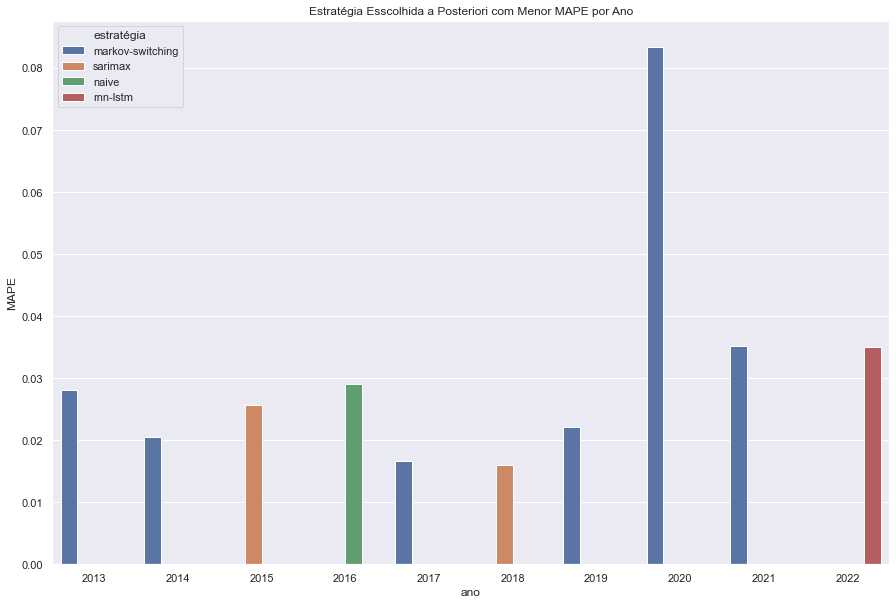

In [73]:
fig = plt.figure(figsize=(15, 10))
ax = sns.barplot(x='ano', y='MAPE', data=dados, hue='estratégia')
ax.set_title('Estratégia Esscolhida a Posteriori com Menor MAPE por Ano')

In [74]:
print(dados.to_latex(escape=False, index=False))

\begin{tabular}{rlllr}
\toprule
  ano &                 metrica &   experimento &        estratégia &      MAPE \\
\midrule
 2013 &         Markov-Mean-Var &  multivariado &  markov-switching &  0.028093 \\
 2014 &         Markov-Mean-Var &  multivariado &  markov-switching &  0.020532 \\
 2015 &  SARIMAX(0,1,1),(1,0,1) &    univariado &           sarimax &  0.025731 \\
 2016 &                    Mean &    univariado &             naive &  0.029089 \\
 2017 &            Markov-Fixed &  multivariado &  markov-switching &  0.016576 \\
 2018 &  SARIMAX(0,1,1),(1,0,1) &  multivariado &           sarimax &  0.016031 \\
 2019 &            Markov-Fixed &  multivariado &  markov-switching &  0.022189 \\
 2020 &            Markov-Fixed &  multivariado &  markov-switching &  0.083437 \\
 2021 &            Markov-Fixed &  multivariado &  markov-switching &  0.035176 \\
 2022 &                RNN-LSTM &  multivariado &          rnn-lstm &  0.035033 \\
\bottomrule
\end{tabular}

